In [1]:
# Part B 
# Exploring the dataset

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualisation style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
df = pd.read_csv("online_shoppers_intention.csv")

# Display the first five rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Display dataset dimensions
print(f"Dataset shape: {df.shape}")
print(f"Number of rows (sessions): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")

Dataset shape: (12330, 18)
Number of rows (sessions): 12330
Number of columns (features): 18


In [5]:
# Display data types
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [7]:
# Display summary statistics for numerical features
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Revenue distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage of purchases: 15.47%


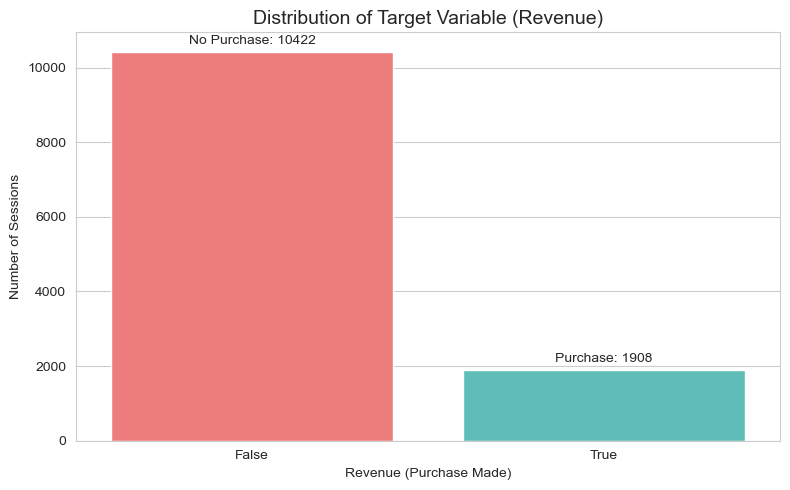

In [8]:
# Count values for the target variable
revenue_counts = df['Revenue'].value_counts()

print("Revenue distribution:")
print(revenue_counts)
print(f"\nPercentage of purchases: {revenue_counts[1] / len(df) * 100:.2f}%")

# Visualise target variable distribution
plt.figure(figsize=(8, 5))

# Count plot
sns.countplot(data=df, x='Revenue', palette=['#FF6B6B', '#4ECDC4'])

plt.title('Distribution of Target Variable (Revenue)', fontsize=14)
plt.xlabel('Revenue (Purchase Made)')
plt.ylabel('Number of Sessions')

# Add labels on bars
plt.text(0, revenue_counts[0] + 200, f'No Purchase: {revenue_counts[0]}', ha='center')
plt.text(1, revenue_counts[1] + 200, f'Purchase: {revenue_counts[1]}', ha='center')

plt.tight_layout()
plt.show()

In [9]:
# Numerical variables
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Variables:")
print(numerical_features)

print(f"\nTotal number of numerical variables: {len(numerical_features)}")

Numerical Variables:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

Total number of numerical variables: 14


In [10]:
# Categorical variables
categorical_features = df.select_dtypes(include=['object', 'bool']).columns

print("Categorical Variables:")
print(categorical_features)

print(f"\nTotal number of categorical variables: {len(categorical_features)}")

Categorical Variables:
Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')

Total number of categorical variables: 4


In [11]:
# Developing Classification Performances 

In [12]:
print('Revenue distribution:\n', df['Revenue'].value_counts(normalize=True))

Revenue distribution:
 Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


In [21]:
# Create a copy of the dataset for preprocessing
df_encoded = df.copy()

# 1. Encode 'Weekend' (boolean to binary)
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)

# 2. Encode 'VisitorType' using One-Hot Encoding
visitor_dummies = pd.get_dummies(df_encoded['VisitorType'], prefix='VisitorType', drop_first=True)
df_encoded = pd.concat([df_encoded, visitor_dummies], axis=1)
df_encoded.drop('VisitorType', axis=1, inplace=True)

# 3. Encode 'Month' using One-Hot Encoding (handle cyclical nature if needed)
month_dummies = pd.get_dummies(df_encoded['Month'], prefix='Month', drop_first=True)
df_encoded = pd.concat([df_encoded, month_dummies], axis=1)
df_encoded.drop('Month', axis=1, inplace=True)

# Verify the encoded dataset
print(f"Dataset shape after encoding: {df_encoded.shape}")
print(df_encoded.head())

Dataset shape after encoding: (12330, 27)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  \
0         0.20       0.20         0.0         0.0  ...   
1         0.00       0.10         0.0         0.0  ...

In [22]:
# Separate features (X) and target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (12330, 26)
Target shape: (12330,)
Target distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [23]:
# Split data into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} sessions")
print(f"Testing set size: {X_test.shape[0]} sessions")
print(f"Training set - Purchase proportion: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Testing set - Purchase proportion: {y_test.sum() / len(y_test) * 100:.2f}%")

Training set size: 8631 sessions
Testing set size: 3699 sessions
Training set - Purchase proportion: 15.48%
Testing set - Purchase proportion: 15.46%


In [24]:
# Identify numerical columns for scaling (excluding encoded categoricals)
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 
                  'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                  'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
                  'OperatingSystems', 'Browser', 'Region', 'TrafficType']

# Create scaler and fit on training data only
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling completed. Training and test sets prepared.")
print(f"Training features mean (scaled): {X_train_scaled[numerical_cols].mean().mean():.4f}")
print(f"Training features std (scaled): {X_train_scaled[numerical_cols].std().mean():.4f}")

Scaling completed. Training and test sets prepared.
Training features mean (scaled): 0.0000
Training features std (scaled): 1.0001


In [25]:
# DEVELOPING CLASSIFICATION MODELS

In [26]:
# Model 1: Logistic Regression
# Initialise and train Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
lr_pred = lr_model.predict(X_test_scaled)

# Display prediction results
print("Logistic Regression - Prediction Results:")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of purchase predictions: {lr_pred.sum()}")
print("\nFirst 10 predictions:")
print(lr_pred[:10])

Logistic Regression - Prediction Results:
Number of test samples: 3699
Number of purchase predictions: 830

First 10 predictions:
[False False  True False  True False False False False False]


In [28]:
# Model 2: Support Vector Machine ( Linear Kernel) 
# Initialise and train SVM with Linear kernel
svm_model = SVC(kernel='linear', random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

# Generate predictions
svm_pred = svm_model.predict(X_test_scaled)

# Display prediction results
print("Support Vector Machine - Prediction Results:")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of purchase predictions: {svm_pred.sum()}")
print("\nFirst 10 predictions:")
print(svm_pred[:10])

Support Vector Machine - Prediction Results:
Number of test samples: 3699
Number of purchase predictions: 739

First 10 predictions:
[False False  True False  True False False False False False]


In [29]:
# Model 3: Decision Tree Classifier
# Initialise and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
dt_model.fit(X_train_scaled, y_train)

# Generate predictions
dt_pred = dt_model.predict(X_test_scaled)

# Display prediction results
print("Decision Tree - Prediction Results:")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of purchase predictions: {dt_pred.sum()}")
print("\nFirst 10 predictions:")
print(dt_pred[:10])

Decision Tree - Prediction Results:
Number of test samples: 3699
Number of purchase predictions: 838

First 10 predictions:
[False False  True False  True False False False False False]


In [30]:
# EVALUATING MODEL PERFORMANCE

In [32]:
# Evaluation Metrics
# Define function to calculate and display metrics
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {'Model': model_name, 'Accuracy': accuracy, 
            'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# Evaluate all three models
lr_metrics = evaluate_model(y_test, lr_pred, 'Logistic Regression')
svm_metrics = evaluate_model(y_test, svm_pred, 'SVM (Linear)')
dt_metrics = evaluate_model(y_test, dt_pred, 'Decision Tree')


Logistic Regression Performance Metrics:
Accuracy:  0.8535
Precision: 0.5181
Recall:    0.7517
F1-Score:  0.6134

SVM (Linear) Performance Metrics:
Accuracy:  0.8683
Precision: 0.5575
Recall:    0.7203
F1-Score:  0.6285

Decision Tree Performance Metrics:
Accuracy:  0.8443
Precision: 0.4976
Recall:    0.7290
F1-Score:  0.5915


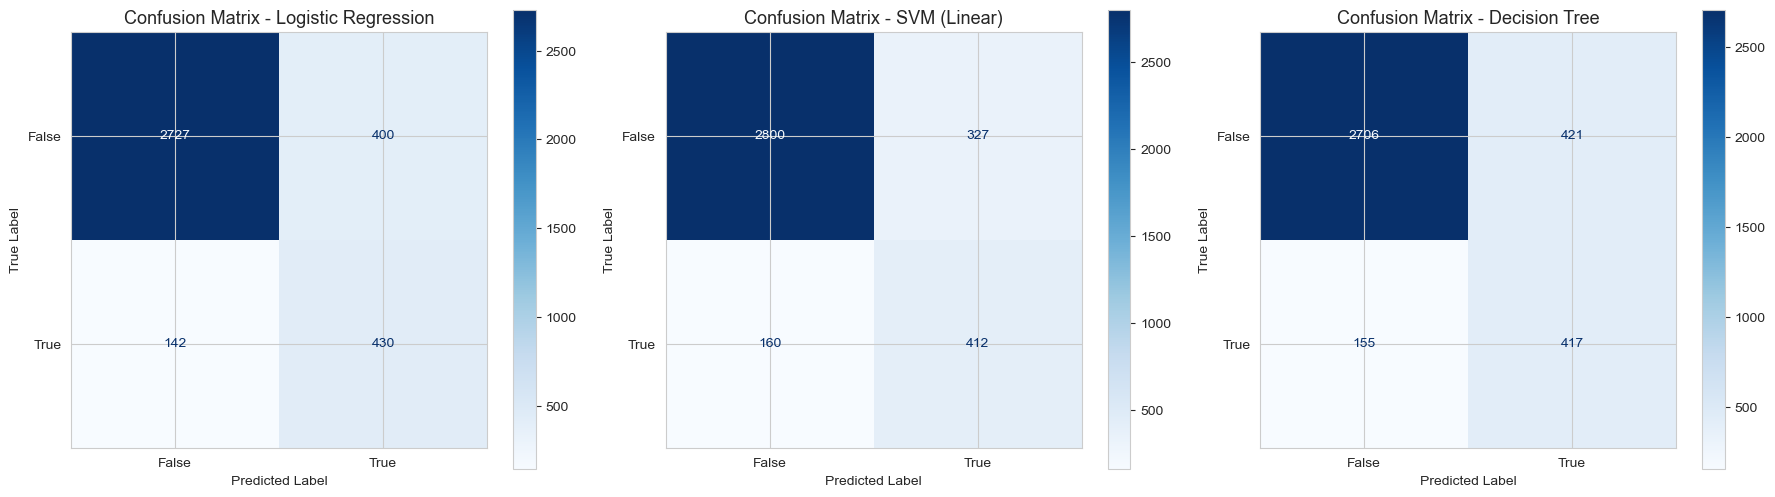

In [33]:
# Confusion Matrices 
# Plot confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [('Logistic Regression', lr_pred), ('SVM (Linear)', svm_pred), ('Decision Tree', dt_pred)]

for idx, (name, pred) in enumerate(models):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[idx], 
                                            cmap='Blues', values_format='d')
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=13)
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [36]:
# Performance Comparison Table 
# Create comparison table
comparison_df = pd.DataFrame([lr_metrics, svm_metrics, dt_metrics])
comparison_df = comparison_df.set_index('Model')

# Highlight best values in each column
def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: #90EE90' if v else '' for v in is_max]
comparison_df.style

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.853474,0.518072,0.751748,0.613409
SVM (Linear),0.868343,0.557510,0.720280,0.628528
Decision Tree,0.844282,0.497613,0.729021,0.591489


In [ ]:
# The End ! 